# Iteration 3: Early Prediction of Higher Education Dropout

This notebook runs the complete Iteration 3 analysis and presents the main outputs in a report-ready format. The operational target is **Dropout vs Not Dropout**, using enrolment and first-semester information only.

> Before running, install the dependencies listed in `iteration3.py`. Set `LOCAL_CSV` in that script when using a downloaded local dataset.

# 1. Business Understanding

The business objective is to identify students who may be at risk of dropping out early enough for the institution to provide effective support. The operational prediction task is binary: **Dropout** versus **Not Dropout**.

The model is intended to support early intervention, not to replace academic or pastoral judgement. The analysis therefore prioritises dropout recall while monitoring precision, lift, stability, and the risk of using information that would not be available early in a student’s study.

The project goals are to:

- identify students who may benefit from early support;
- use enrolment and first-semester information only for prediction;
- compare suitable classification algorithms using training data;
- select an intervention threshold using validation data; and
- evaluate the final frozen model once on an untouched test set.

The original three-class outcome, `Dropout`, `Enrolled`, and `Graduate`, is retained for descriptive analysis, while `is_dropout` is used as the operational modelling target.

# 2. Data Understanding

The analysis loads the UCI higher-education student dataset, standardises field names, preserves the original outcome, and creates a binary operational target. The following code cell runs the reproducible data-loading and modelling workflow; the Data Descriptor subsection documents the resulting analytical dataframe.

Raw shape: (4424, 37)
   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2               

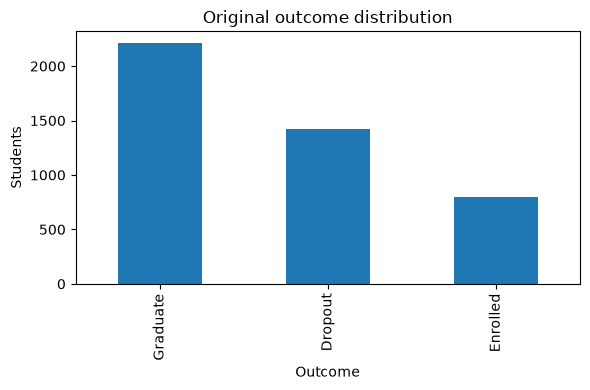


Dropout rate by tuition_fees_up_to_date:
                         dropout_rate  count
tuition_fees_up_to_date                     
0                            0.865530    528
1                            0.247433   3896


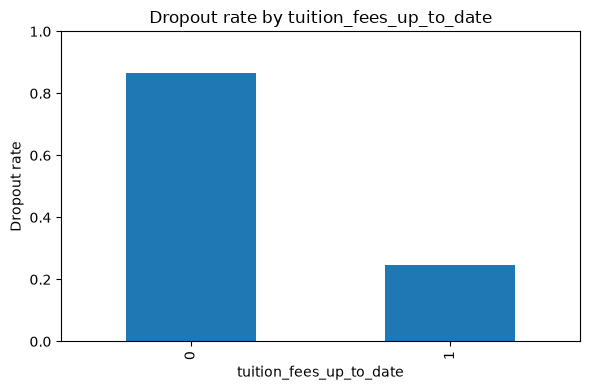


Dropout rate by debtor:
        dropout_rate  count
debtor                     
1           0.620278    503
0           0.282836   3921


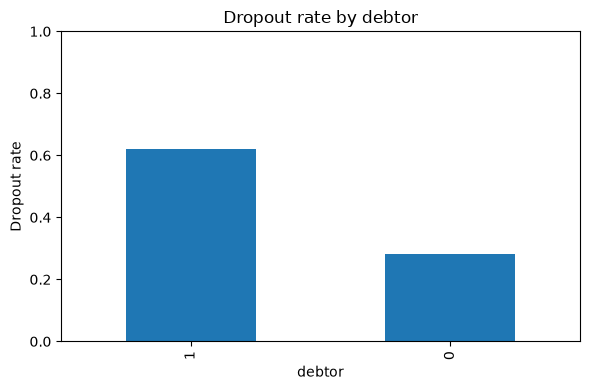


Dropout rate by scholarship_holder:
                    dropout_rate  count
scholarship_holder                     
0                       0.387068   3325
1                       0.121929   1099


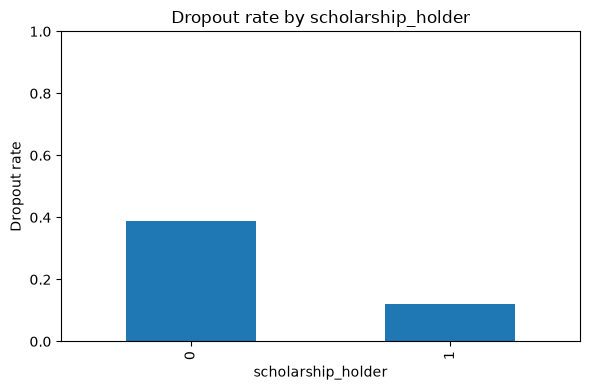


Dropout rate by daytime_evening_attendance:
                            dropout_rate  count
daytime_evening_attendance                     
0                               0.428571    483
1                               0.308044   3941


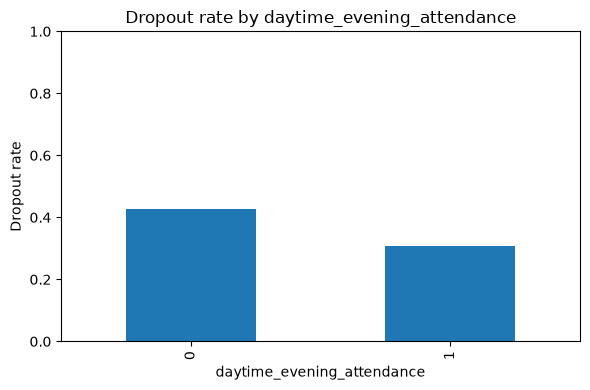

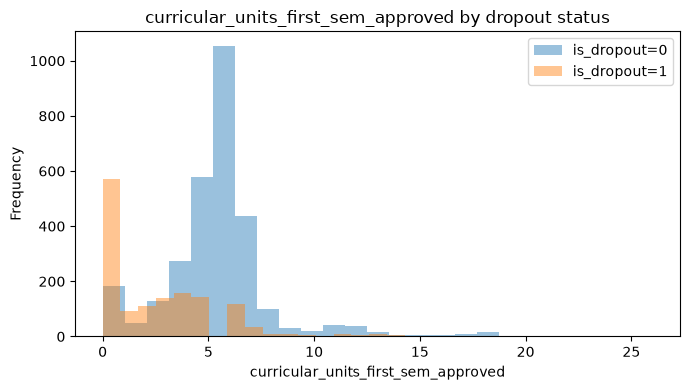

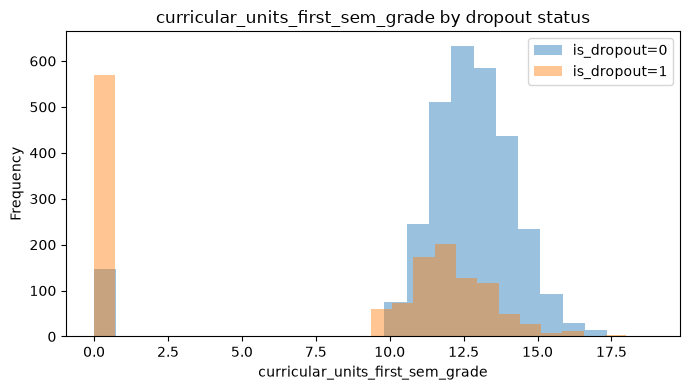

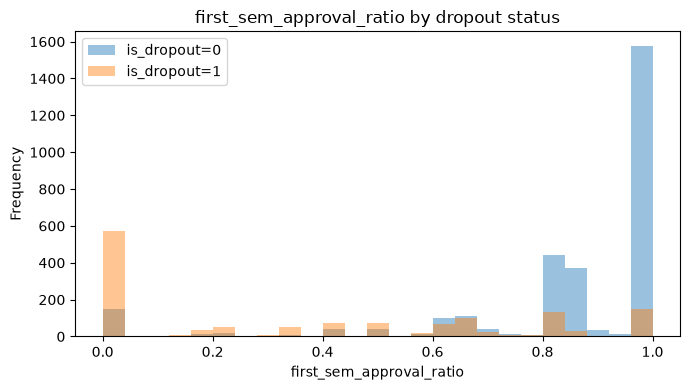

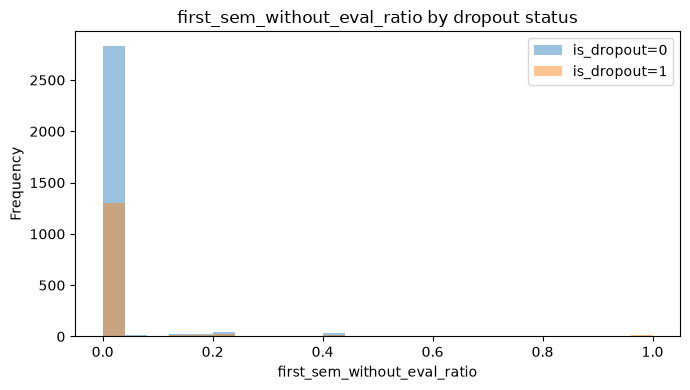


Dropout rate by age_quantile_group:
                    dropout_rate  count
age_quantile_group                     
(25.0, 70.0]            0.558852   1045
(20.0, 25.0]            0.356280    828
(19.0, 20.0]            0.222037    599
(16.999, 19.0]          0.209529   1952

Dropout rate by course:
                                      dropout_rate  count
course_name                                              
Biofuel Production Technologies           0.666667     12
Equinculture                              0.553191    141
Informatics Engineering                   0.541176    170
Management (evening attendance)           0.507463    268
Basic Education                           0.442708    192
Agronomy                                  0.409524    210
Oral Hygiene                              0.383721     86
Animation and Multimedia Design           0.381395    215
Tourism                                   0.380952    252
Advertising and Marketing Management      0.354478    268
Ma


TRAIN-only cross-validation comparison:
                model  cv_average_precision  cv_average_precision_std  \
0             XGBoost              0.851338                  0.016882   
1        RandomForest              0.845895                  0.017370   
2  LogisticRegression              0.839391                  0.017808   

   cv_roc_auc  cv_roc_auc_std  cv_recall  cv_recall_std  cv_precision  \
0    0.894929        0.011959   0.743351       0.036327      0.761883   
1    0.892725        0.010824   0.724589       0.033480      0.779453   
2    0.888218        0.013143   0.778521       0.039843      0.717673   

   cv_precision_std     cv_f2  cv_f2_std  
0          0.019354  0.746530   0.028361  
1          0.010605  0.734677   0.027649  
2          0.010043  0.765002   0.028660  
Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best XGBoost parameters:
{'model__subsample': 0.7, 'model__scale_pos_weight': 1.689097303634232, 'model__reg_lambda': 1, 'model__n_estimators': 250, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Best TRAIN CV average precision: 0.8540862317439875



Chosen validation threshold: 0.27
Reason: No threshold met both criteria; maximize precision while preserving recall >= 0.85
threshold    0.270000
precision    0.626289
recall       0.855634
f1           0.723214
f2           0.797244
accuracy     0.789831
Name: 22, dtype: float64


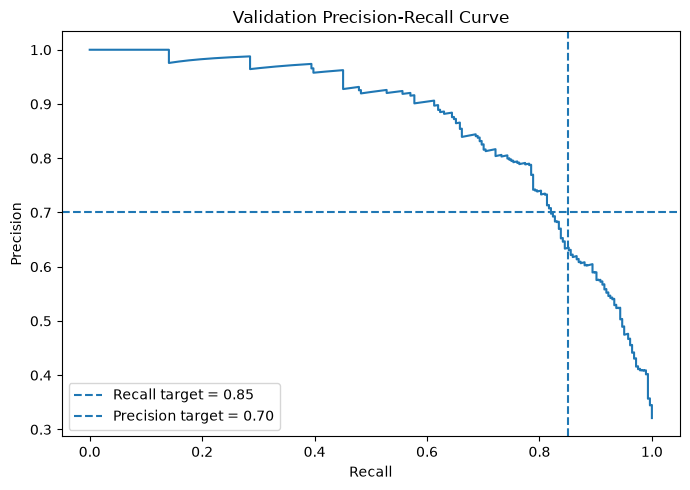


FINAL TEST METRICS — test set used only here:
accuracy            : 0.8056
precision           : 0.6436
recall              : 0.8838
f1                  : 0.7448
f2                  : 0.8224
average_precision   : 0.8849
roc_auc             : 0.9142
lift_at_20pct       : 3.0106
train_accuracy      : 0.8313
stability_gap       : 0.0257


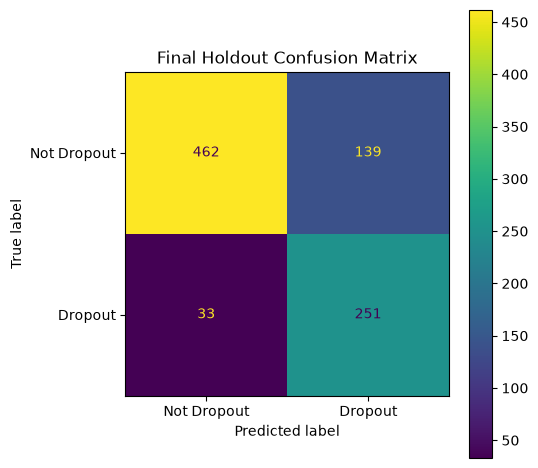


Success criteria:
                 criterion   target    actual  passed
0           Lift @ top 20%    > 2.5  3.010563    True
1           Dropout recall  >= 0.85  0.883803    True
2        Dropout precision  >= 0.70  0.643590   False
3  Train-test accuracy gap   < 0.10  0.025659    True

Conclusion: at least one predefined criterion was not met. Do NOT claim the model is fully deployment-ready. Report the trade-off and recommend further iteration or pilot validation.

Interpretable companion tree holdout diagnostics:
Accuracy : 0.8338983050847457
Precision: 0.7546468401486989
Recall   : 0.7147887323943662

Top 20 final-model features:
                                        feature  importance
17                num__first_sem_approval_ratio    0.245095
18              num__first_sem_unapproved_units    0.078499
84               cat__tuition_fees_up_to_date_0    0.047386
88                   cat__financial_risk_flag_0    0.046270
11     num__curricular_units_first_sem_approved    0.027

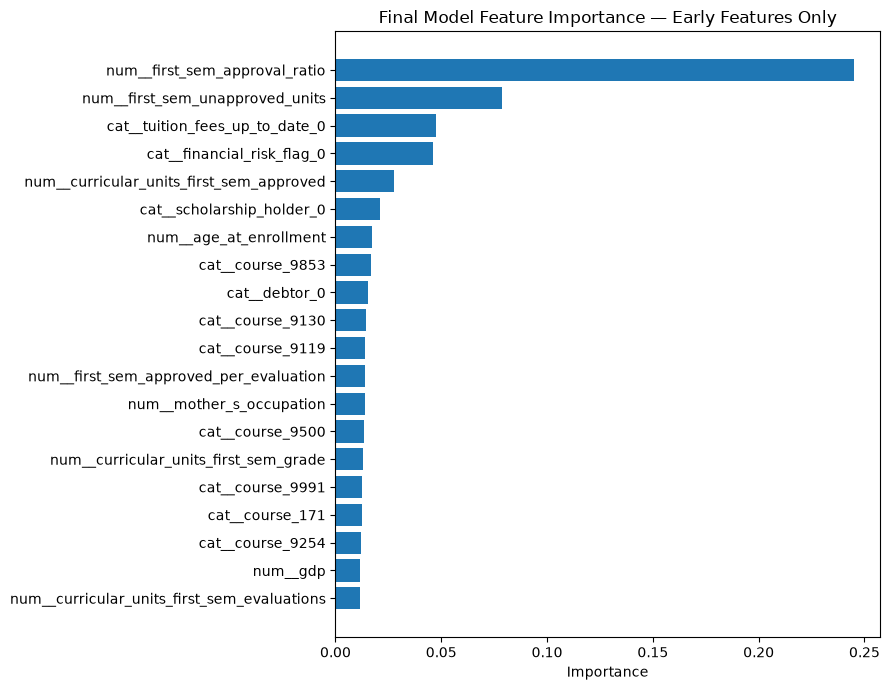


Saved report tables to iteration3_outputs/


In [1]:
%matplotlib inline
from pathlib import Path
import runpy

SCRIPT_PATH = Path('iteration3.py')
if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f'Could not find {SCRIPT_PATH.resolve()}')

analysis = runpy.run_path(str(SCRIPT_PATH), run_name='__main__')
globals().update(analysis)

## 2.1 Data Descriptor

This section describes the analytical dataset before model comparison. It reports the dataset dimensions, variable data types, missingness, unique values, example values, and summary statistics in a format suitable for the data description section of the report.

In [2]:
from IPython.display import display

output_dir = Path('iteration3_outputs')
output_dir.mkdir(exist_ok=True)

missing_cells = int(df.isna().sum().sum())
overview = pd.DataFrame({
    'item': [
        'Rows',
        'Columns',
        'Missing cells',
        'Duplicate rows',
        'Original outcome classes',
        'Dropout students',
        'Dropout rate',
    ],
    'value': [
        len(df),
        df.shape[1],
        missing_cells,
        int(df.duplicated().sum()),
        df['target_original'].nunique(dropna=False),
        int(df['is_dropout'].sum()),
        round(df['is_dropout'].mean(), 3),
    ],
})
print('Dataset overview')
display(overview)

def variable_role(column):
    if column == 'is_dropout':
        return 'Operational target'
    if column in {'target', 'target_original'}:
        return 'Outcome descriptor'
    if column == 'course_name':
        return 'Reporting label'
    if column in second_semester_fields:
        return 'Excluded: second-semester leakage'
    if column in governance_exclusions:
        return 'Excluded: governance'
    return 'Early-warning feature candidate'

variable_dictionary = pd.DataFrame({
    'variable': df.columns,
    'data_type': [str(df[column].dtype) for column in df.columns],
    'role': [variable_role(column) for column in df.columns],
    'missing_values': [int(df[column].isna().sum()) for column in df.columns],
    'unique_values': [int(df[column].nunique(dropna=False)) for column in df.columns],
    'example_values': [
        ', '.join(df[column].dropna().astype(str).drop_duplicates().head(3))
        for column in df.columns
    ],
})
print('Variable dictionary')
display(variable_dictionary)

numeric_summary = (
    df.select_dtypes(include='number')
      .describe()
      .T.reset_index()
      .rename(columns={'index': 'variable'})
      .round(3)
)
print('Numeric variable summary')
display(numeric_summary)

overview.to_csv(output_dir / 'data_overview.csv', index=False)
variable_dictionary.to_csv(output_dir / 'data_dictionary.csv', index=False)
numeric_summary.to_csv(output_dir / 'numeric_data_summary.csv', index=False)
print('Saved data descriptor tables to iteration3_outputs/')

Dataset overview


,item,value
0,Rows,4424.000
1,Columns,46.000
2,Missing cells,0.000
3,Duplicate rows,0.000
4,Original outcome classes,3.000
5,Dropout students,1421.000
6,Dropout rate,0.321


Variable dictionary

,variable,data_type,role,missing_values,unique_values,example_values
0,marital_status,int64,Early-warning feature candidate,0,6,"1, 2, 4"
1,application_mode,int64,Early-warning feature candidate,0,18,"17, 15, 1"
2,application_order,int64,Early-warning feature candidate,0,8,"5, 1, 2"
3,course,int64,Early-warning feature candidate,0,17,"171, 9254, 9070"
4,daytime_evening_attendance,int64,Early-warning feature candidate,0,2,"1, 0"
5,previous_qualification,int64,Early-warning feature candidate,0,17,"1, 19, 42"
6,previous_qualification_grade,float64,Early-warning feature candidate,0,101,"122.0, 160.0, 100.0"
7,nacionality,int64,Excluded: governance,0,21,"1, 62, 6"
8,mother_s_qualification,int64,Early-warning feature candidate,0,29,"19, 1, 37"
9,father_s_qualification,int64,Early-warning feature candidate,0,34,"12, 3, 37"


Numeric variable summary


,variable,count,mean,std,min,25%,50%,75%,max
0,marital_status,4424.0,1.179,0.606,1.00,1.000,1.000,1.000,6.000
1,application_mode,4424.0,18.669,17.485,1.00,1.000,17.000,39.000,57.000
2,application_order,4424.0,1.728,1.314,0.00,1.000,1.000,2.000,9.000
3,course,4424.0,8856.643,2063.566,33.00,9085.000,9238.000,9556.000,9991.000
4,daytime_evening_attendance,4424.0,0.891,0.312,0.00,1.000,1.000,1.000,1.000
5,previous_qualification,4424.0,4.578,10.217,1.00,1.000,1.000,1.000,43.000
6,previous_qualification_grade,4424.0,132.613,13.188,95.00,125.000,133.100,140.000,190.000
7,nacionality,4424.0,1.873,6.915,1.00,1.000,1.000,1.000,109.000
8,mother_s_qualification,4424.0,19.562,15.603,1.00,2.000,19.000,37.000,44.000
9,father_s_qualification,4424.0,22.275,15.343,1.00,3.000,19.000,37.000,44.000


Saved data descriptor tables to iteration3_outputs/


# 3. Data Preparation

The student-level data is organised into logical components and assembled into one analytical table. The integration step retains the student row index and validates that no rows, columns, or values are lost.

In [3]:
integration_source = df.copy()
original_columns = integration_source.columns.tolist()

# Define logical column groups for the integrated analytical table.
demographic_columns = [
    column for column in integration_source.columns
    if column in {
        'marital_status', 'nacionality', 'gender', 'age_at_enrollment',
        'international', 'displaced', 'educational_special_needs',
    }
]
academic_columns = [
    column for column in integration_source.columns
    if 'qualification' in column
    or 'admission_grade' in column
    or 'curricular_units' in column
    or 'first_sem_' in column
    or 'second_sem_' in column
]
financial_context_columns = [
    column for column in integration_source.columns
    if column in {
        'debtor', 'tuition_fees_up_to_date', 'scholarship_holder',
        'financial_risk_flag', 'unemployment_rate', 'inflation_rate', 'gdp',
    }
]
outcome_columns = [
    column for column in integration_source.columns
    if column in {'target', 'target_original', 'is_dropout', 'course_name', 'age_quantile_group'}
]
assigned_columns = set(
    demographic_columns
    + academic_columns
    + financial_context_columns
    + outcome_columns
)
remaining_columns = [
    column for column in integration_source.columns
    if column not in assigned_columns
]

# Keep any uncategorised fields in a general application/context component.
application_context_columns = remaining_columns

component_tables = {
    'demographic': integration_source[demographic_columns].copy(),
    'academic': integration_source[academic_columns].copy(),
    'financial_context': integration_source[financial_context_columns].copy(),
    'application_context': integration_source[application_context_columns].copy(),
    'outcome_and_labels': integration_source[outcome_columns].copy(),
}

assembled_data = pd.concat(component_tables.values(), axis=1)
assembled_data = assembled_data.loc[:, original_columns]

integration_summary = pd.DataFrame({
    'component': list(component_tables),
    'columns': [table.shape[1] for table in component_tables.values()],
    'rows': [table.shape[0] for table in component_tables.values()],
})
display(integration_summary)

integration_matches = assembled_data.equals(integration_source)
assert integration_matches, 'Assembled data does not match the source dataframe.'
assert assembled_data.columns.tolist() == original_columns
assert assembled_data.index.equals(integration_source.index)
print(f'Integration verified: {len(component_tables)} components assembled into {assembled_data.shape[0]} rows and {assembled_data.shape[1]} columns.')

for component_name, component_table in component_tables.items():
    component_table.to_csv(output_dir / f'integration_{component_name}.csv', index=True)
assembled_data.to_csv(output_dir / 'integrated_assembled_data.csv', index=True)
print('Saved split components and assembled data to iteration3_outputs/')

,component,columns,rows
0,demographic,7,4424
1,academic,21,4424
2,financial_context,7,4424
3,application_context,6,4424
4,outcome_and_labels,5,4424


Integration verified: 5 components assembled into 4424 rows and 46 columns.


Saved split components and assembled data to iteration3_outputs/


## 3.1 Integration report

The following report summarises the integration process and its validation results. It can be copied into the methodology or data preparation section of the final report.

In [4]:
component_lines = '\n'.join(
    f"| {row.component} | {row.columns} | {row.rows} |"
    for row in integration_summary.itertuples()
)
integration_report = f"""# Data Integration Report

## Purpose

The student dataset was organised into logical column groups to make the data preparation process transparent and reproducible. The groups were assembled horizontally using the student row index before modelling.

## Integration method

The analytical dataframe contained {integration_source.shape[0]:,} student records and {integration_source.shape[1]} columns. It was split into five components: demographic, academic, financial/context, application/context, and outcome/label information. Each component retained the original row index, so the tables could be combined with `pd.concat(..., axis=1)` without changing the student-level observations.

| Component | Columns | Rows |
|---|---:|---:|
{component_lines}

## Assembly and validation

The component tables were concatenated horizontally and reordered to the original column sequence. The reconstructed dataframe was then compared with the source dataframe. The validation confirmed that the assembled table had the same {assembled_data.shape[0]:,} rows, {assembled_data.shape[1]} columns, index, column order, and values as the source table.

**Integration result:** PASS

## Output files

The split component tables and reconstructed integrated table were exported to `iteration3_outputs/`. These files provide an auditable record of the integration process and can be used to reproduce the analysis.
"""
print(integration_report)
(output_dir / 'data_integration_report.md').write_text(integration_report, encoding='utf-8')
print('Saved data integration report to iteration3_outputs/data_integration_report.md')

# Data Integration Report

## Purpose

The student dataset was organised into logical column groups to make the data preparation process transparent and reproducible. The groups were assembled horizontally using the student row index before modelling.

## Integration method

The analytical dataframe contained 4,424 student records and 46 columns. It was split into five components: demographic, academic, financial/context, application/context, and outcome/label information. Each component retained the original row index, so the tables could be combined with `pd.concat(..., axis=1)` without changing the student-level observations.

| Component | Columns | Rows |
|---|---:|---:|
| demographic | 7 | 4424 |
| academic | 21 | 4424 |
| financial_context | 7 | 4424 |
| application_context | 6 | 4424 |
| outcome_and_labels | 5 | 4424 |

## Assembly and validation

The component tables were concatenated horizontally and reordered to the original column sequence. The reconstructed dataframe was t

# 4. Data Transformation

The workflow transforms the prepared data into an early-warning modelling dataset. Column names are standardised, the original outcome is converted into the binary `is_dropout` target, and first-semester features are constructed, including approval ratios, unapproved units, approved units per evaluation, non-evaluation ratios, and a financial-risk flag.

Second-semester variables are explicitly excluded from the model to prevent target leakage. Categorical variables are imputed and one-hot encoded. Numeric variables are imputed; the logistic regression pipeline additionally applies a Yeo-Johnson power transformation. All preprocessing is fitted inside pipelines using training folds only.

# 5. Data Mining Selection Method

The candidate algorithms are compared using stratified cross-validation on the training split only. Average precision is the primary selection metric because the intervention target is imbalanced.

In [5]:
from IPython.display import display

comparison_report = comparison.copy()
metric_columns = comparison_report.select_dtypes(include='number').columns
comparison_report[metric_columns] = comparison_report[metric_columns].round(3)
display(comparison_report)

,model,cv_average_precision,cv_average_precision_std,cv_roc_auc,cv_roc_auc_std,cv_recall,cv_recall_std,cv_precision,cv_precision_std,cv_f2,cv_f2_std
0,XGBoost,0.851,0.017,0.895,0.012,0.743,0.036,0.762,0.019,0.747,0.028
1,RandomForest,0.846,0.017,0.893,0.011,0.725,0.033,0.779,0.011,0.735,0.028
2,LogisticRegression,0.839,0.018,0.888,0.013,0.779,0.040,0.718,0.010,0.765,0.029


## 5.1 RandomizedSearchCV tuning results

`RandomizedSearchCV` tests XGBoost hyperparameter combinations using stratified cross-validation on the training set only. The table and plot show the strongest combinations ranked by mean validation average precision.

In [6]:
if 'search' in globals() and hasattr(search, 'cv_results_'):
    tuning_results = pd.DataFrame(search.cv_results_).sort_values(
        'rank_test_score'
    ).head(10).copy()
    tuning_results.insert(0, 'rank', tuning_results['rank_test_score'])
    tuning_results['mean_average_precision'] = tuning_results['mean_test_score'].round(3)
    tuning_results['std_average_precision'] = tuning_results['std_test_score'].round(3)
    tuning_report = tuning_results[
        ['rank', 'mean_average_precision', 'std_average_precision', 'params']
    ]
    display(tuning_report)
else:
    print('RandomizedSearchCV results are unavailable. Run the analysis cell first.')

,rank,mean_average_precision,std_average_precision,params
10,1,0.854,0.017,"{'model__subsample': 0.7, 'model__scale_pos_we..."
11,2,0.854,0.020,"{'model__subsample': 0.7, 'model__scale_pos_we..."
15,3,0.853,0.017,"{'model__subsample': 0.85, 'model__scale_pos_w..."
14,4,0.851,0.019,"{'model__subsample': 0.7, 'model__scale_pos_we..."
27,5,0.851,0.018,"{'model__subsample': 1.0, 'model__scale_pos_we..."
26,6,0.851,0.018,"{'model__subsample': 1.0, 'model__scale_pos_we..."
16,7,0.851,0.018,"{'model__subsample': 1.0, 'model__scale_pos_we..."
6,8,0.850,0.020,"{'model__subsample': 1.0, 'model__scale_pos_we..."
29,9,0.850,0.017,"{'model__subsample': 0.85, 'model__scale_pos_w..."
4,10,0.849,0.020,"{'model__subsample': 0.85, 'model__scale_pos_w..."


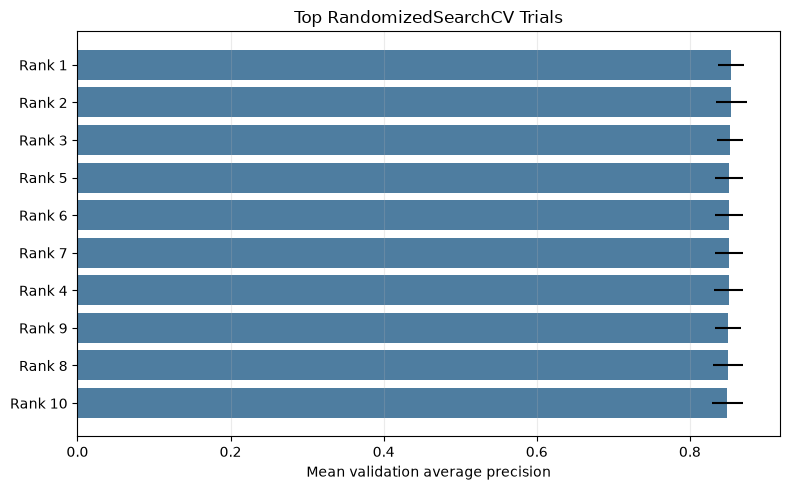

In [7]:
if 'search' in globals() and hasattr(search, 'cv_results_'):
    plot_data = tuning_report.sort_values('mean_average_precision')
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(
        range(len(plot_data)),
        plot_data['mean_average_precision'],
        xerr=plot_data['std_average_precision'],
        color='#2f6690',
        alpha=0.85,
    )
    ax.set_yticks(range(len(plot_data)))
    ax.set_yticklabels([f"Rank {rank}" for rank in plot_data['rank']])
    ax.set_xlabel('Mean validation average precision')
    ax.set_title('Top RandomizedSearchCV Trials')
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print('RandomizedSearchCV plot is unavailable. Run the analysis cell first.')

## 5.2 Export RandomizedSearchCV results

The complete tuning results are saved as a CSV file for use in the report appendix or further analysis.

In [8]:
if 'search' in globals() and hasattr(search, 'cv_results_'):
    import json

    output_dir = Path('iteration3_outputs')
    output_dir.mkdir(exist_ok=True)
    randomized_search_results = pd.DataFrame(search.cv_results_).copy()
    randomized_search_results['params'] = randomized_search_results['params'].map(
        lambda value: json.dumps(value, sort_keys=True, default=str)
    )
    search_csv_path = output_dir / 'randomized_search_cv_results.csv'
    randomized_search_results.to_csv(search_csv_path, index=False)
    print(f'Saved {len(randomized_search_results)} RandomizedSearchCV trials to {search_csv_path}')
else:
    print('RandomizedSearchCV results are unavailable. Run the analysis cell first.')

Saved 30 RandomizedSearchCV trials to iteration3_outputs/randomized_search_cv_results.csv


# 6. Data Mining Algorithm

The selected model is refitted after model selection, and the classification threshold is chosen using validation data only. This section presents the operational decision threshold and supporting dropout-rate outputs.

In [9]:
print(f'Chosen threshold: {chosen_threshold:.2f}')
print(f'Reason: {threshold_reason}')
threshold_report = threshold_table.sort_values(
    ['f2', 'precision'], ascending=False
).head(10).copy()
threshold_report[threshold_report.select_dtypes(include='number').columns] = (
    threshold_report.select_dtypes(include='number').round(3)
)
display(threshold_report)

Chosen threshold: 0.27
Reason: No threshold met both criteria; maximize precision while preserving recall >= 0.85


,threshold,precision,recall,f1,f2,accuracy
14,0.19,0.572,0.912,0.703,0.815,0.753
16,0.21,0.586,0.901,0.710,0.814,0.764
18,0.23,0.604,0.891,0.720,0.814,0.777
12,0.17,0.542,0.930,0.685,0.813,0.725
13,0.18,0.549,0.923,0.689,0.812,0.732
17,0.22,0.593,0.894,0.713,0.812,0.769
10,0.15,0.520,0.944,0.671,0.812,0.703
15,0.20,0.579,0.901,0.705,0.811,0.758
11,0.16,0.528,0.937,0.675,0.811,0.711
19,0.24,0.607,0.877,0.718,0.805,0.779


## 6.1 Dropout-rate analysis

These tables summarise dropout rates by age cohort and course to support interpretation of the algorithm’s early-warning context.

In [10]:
age_dropout_rates = (
    df.groupby('age_quantile_group', observed=False)['is_dropout']
      .agg(dropout_rate='mean', students='count')
      .reset_index()
)
age_dropout_rates['dropout_rate'] = age_dropout_rates['dropout_rate'].round(3)
display(age_dropout_rates)

,age_quantile_group,dropout_rate,students
0,"(16.999, 19.0]",0.210,1952
1,"(19.0, 20.0]",0.222,599
2,"(20.0, 25.0]",0.356,828
3,"(25.0, 70.0]",0.559,1045


In [11]:
course_dropout_rates = (
    df.groupby('course_name', dropna=False)['is_dropout']
      .agg(dropout_rate='mean', students='count')
      .reset_index()
      .sort_values('dropout_rate', ascending=False)
)
course_dropout_rates['dropout_rate'] = course_dropout_rates['dropout_rate'].round(3)
display(course_dropout_rates)

,course_name,dropout_rate,students
4,Biofuel Production Technologies,0.667,12
6,Equinculture,0.553,141
7,Informatics Engineering,0.541,170
10,Management (evening attendance),0.507,268
3,Basic Education,0.443,192
1,Agronomy,0.410,210
12,Oral Hygiene,0.384,86
2,Animation and Multimedia Design,0.381,215
15,Tourism,0.381,252
0,Advertising and Marketing Management,0.354,268


# 7. Data Mining

The final model is evaluated on the untouched test set after all modelling and threshold decisions are frozen.

In [12]:
report_metrics = pd.DataFrame({
    'Metric': list(test_metrics) + ['train_accuracy', 'stability_gap'],
    'Value': list(test_metrics.values()) + [train_accuracy, stability_gap],
})
report_metrics['Value'] = report_metrics['Value'].round(3)
display(report_metrics)

,Metric,Value
0,accuracy,0.806
1,precision,0.644
2,recall,0.884
3,f1,0.745
4,f2,0.822
5,average_precision,0.885
6,roc_auc,0.914
7,lift_at_20pct,3.011
8,train_accuracy,0.831
9,stability_gap,0.026


## 7.1 Success criteria

This table reports the predefined technical success criteria using the final holdout results.

In [13]:
success_report = success.copy()
success_report['actual'] = success_report['actual'].map(lambda value: f'{value:.3f}')
success_report['passed'] = success_report['passed'].map({True: 'PASS', False: 'FAIL'})
success_report

,criterion,target,actual,passed
0,Lift @ top 20%,> 2.5,3.011,PASS
1,Dropout recall,>= 0.85,0.884,PASS
2,Dropout precision,>= 0.70,0.644,FAIL
3,Train-test accuracy gap,< 0.10,0.026,PASS


## 7.2 Feature interpretation

The feature-importance output supports interpretation of the final model. Only enrolment and first-semester predictors should be described as actionable early-warning factors.

In [14]:
if 'importance' in globals():
    importance_report = importance.head(20).copy()
    importance_report['importance'] = importance_report['importance'].round(4)
    display(importance_report)
else:
    print('Feature importance is unavailable because XGBoost was not used.')

,feature,importance
17,num__first_sem_approval_ratio,0.2451
18,num__first_sem_unapproved_units,0.0785
84,cat__tuition_fees_up_to_date_0,0.0474
88,cat__financial_risk_flag_0,0.0463
11,num__curricular_units_first_sem_approved,0.0278
86,cat__scholarship_holder_0,0.0210
7,num__age_at_enrollment,0.0173
60,cat__course_9853,0.0168
82,cat__debtor_0,0.0156
52,cat__course_9130,0.0143


## 7.3 Report checklist

- Business objective: identify students who may benefit from early support.
- Data understanding: dataset dimensions, variable types, missingness, and distributions documented.
- Data preparation: logical components assembled and verified with an equality check.
- Data transformation: binary target, engineered first-semester features, preprocessing, and leakage controls documented.
- Data mining selection method: cross-validation and RandomizedSearchCV performed using training data only.
- Data mining algorithm: threshold selection performed using validation data only.
- Data mining: final evaluation performed once on the untouched test set.

# 8.5 Optional Hyperparameter Exploration

This optional next-step experiment is isolated from the completed Iteration 3 workflow. It uses only `X_train` and `y_train`, stores its models under new variable names, and does not replace `best_model`, change the selected threshold, or evaluate the validation/test sets.

Set `RUN_ITERATION_8_5 = True` to launch 50 Random Forest candidates and 60 XGBoost candidates with the existing five-fold cross-validation object (550 fits in total). Leave it as `False` when rerunning the Iteration 3 report without the additional experiment.

In [15]:
from iteration8_5_tuning import (
    export_search_results,
    run_hyperparameter_exploration,
    summarize_searches,
)

RUN_ITERATION_8_5 = False
iteration8_5_searches = None

if RUN_ITERATION_8_5:
    iteration8_5_searches = run_hyperparameter_exploration(
        X_train=X_train,
        y_train=y_train,
        preprocessor=tree_preprocessor,
        cv=cv,
        xgboost_n_iter=60,
        random_forest_n_iter=50,
    )
else:
    print('Iteration 8.5 is ready but was not run. Set RUN_ITERATION_8_5 = True to start it.')

Iteration 8.5 is ready but was not run. Set RUN_ITERATION_8_5 = True to start it.


In [16]:
if iteration8_5_searches is not None:
    iteration8_5_summary = summarize_searches(iteration8_5_searches)
    display(iteration8_5_summary)

    iteration8_5_exported_files = export_search_results(
        iteration8_5_searches,
        output_dir='iteration8_5_outputs',
    )
    print('Exported files:')
    for output_path in iteration8_5_exported_files:
        print(f'- {output_path}')
else:
    print('No Iteration 8.5 results are available because the optional search was not run.')

No Iteration 8.5 results are available because the optional search was not run.
